In [3]:
%run ../setup.py
%load_ext autoreload
%autoreload 2
# ============= 
import pandas as pd
import numpy as np
# ============= METRICS ===========================
from sklearn.metrics import (mean_absolute_error, 
                            mean_absolute_percentage_error, 
                            mean_squared_error,
                            r2_score)
# ============= MODEL =============================
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
# ============= TOOLS =============================
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
# ============= REGRESSION SERIES ==================
from utils.data_loader import load_regression_data
# ============= VISUALIZE AND CONFIG PARAMS =======
from src.preprocessing import overview_data
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.figsize': (12, 8),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'legend.fontsize': 12,
    'lines.linewidth': 2,
    'grid.alpha': 0.3,
    'savefig.dpi': 300,
})
# ============= TURN OFF THE WARNING ==============
import warnings
warnings.filterwarnings("ignore")

# ============= CONFIG ============================
FEATURES = ['Total_Spend', 'Frequency', 'Total_Items', 'Unique_Products', 'Avg_Basket_Value']
TARGET   = 'LTV'
SKEW_THR = 1.0

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 0) Load Data and Overview

In [4]:
df = load_regression_data()
overview_data(df)

Kích thước dữ liệu = (3601,7)

Bảng Kiểu dữ liệu
<class 'pandas.DataFrame'>
RangeIndex: 3601 entries, 0 to 3600
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        3601 non-null   int64  
 1   Total_Spend       3601 non-null   float64
 2   Frequency         3601 non-null   int64  
 3   Total_Items       3601 non-null   int64  
 4   Unique_Products   3601 non-null   int64  
 5   Avg_Basket_Value  3601 non-null   float64
 6   LTV               3601 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 197.1 KB
None

Bảng Phân phối dữ liệu
         CustomerID    Total_Spend    Frequency    Total_Items  \
count   3601.000000    3601.000000  3601.000000    3601.000000   
mean   15274.502083    1680.373941     3.614274     994.916968   
std     1723.169318    6934.406737     6.043114    4072.857697   
min    12346.000000       2.900000     1.000000       1.000000   
25%    13778.000000   

# 1) Tiền xử lý dữ liệu
- Lọc LTV > 0 : Tránh gây nhiễu trong quá trình dự đoán
- Xử lý Outlier (IQR) : Tránh Bias
- Log Transform để làm mướt dữ liệu phân phối

Bộ dữ liệu ban đầu : (3601, 7)
Bộ dữ liệu lúc sau : (1846, 7)


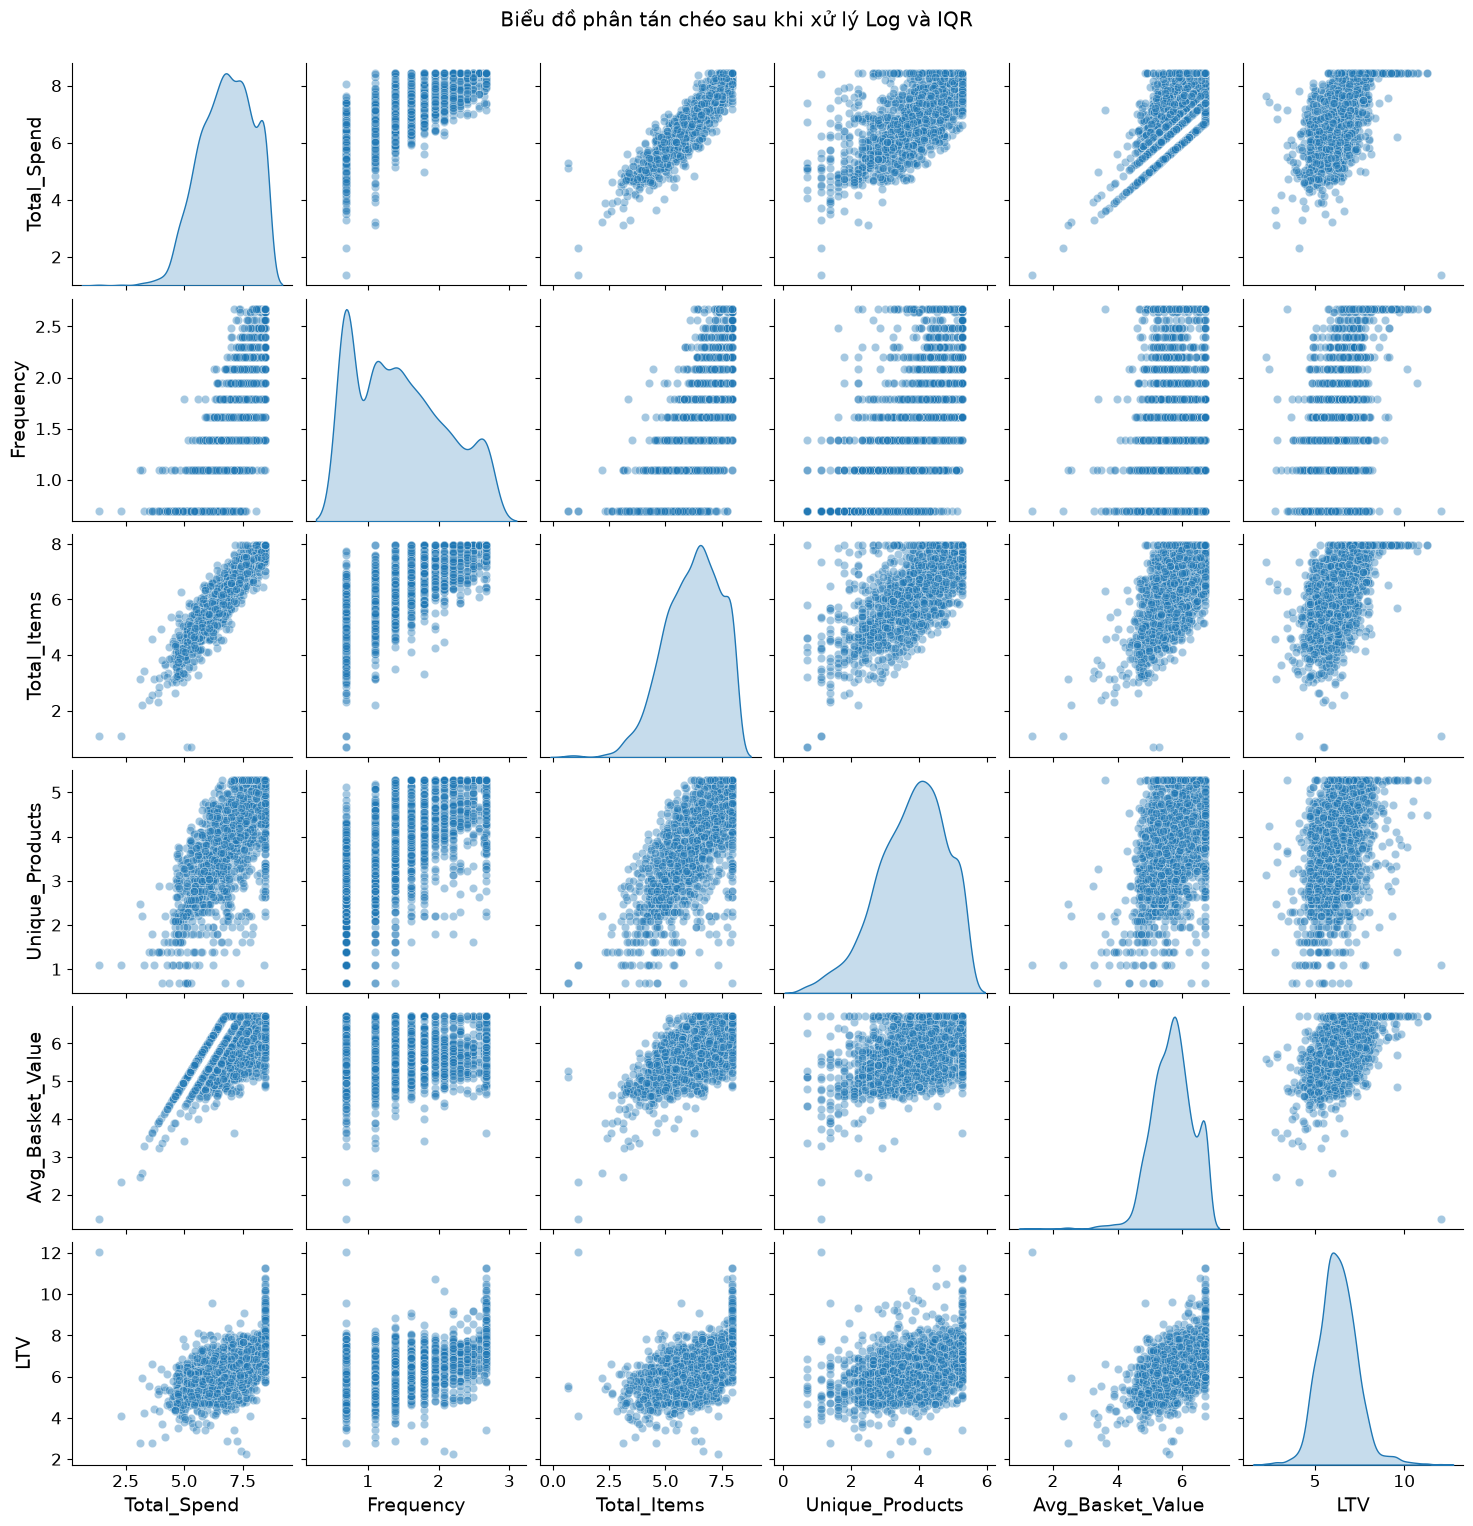

In [5]:
# 1.1. Thu hẹp phạm vi nghiên cứu: Chỉ lấy nhóm khách hàng hoạt động (LTV > 0)
df_active = df[df['LTV'] > 0].copy()

features = ['Total_Spend', 'Frequency', 'Total_Items', 'Unique_Products', 'Avg_Basket_Value']
target = 'LTV'

# 1.2. Xử lý Outlier bằng IQR Capping (Winsorization)
for col in features:
    Q1 = df_active[col].quantile(0.25)
    Q3 = df_active[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_active[col] = np.clip(df_active[col], lower_bound, upper_bound)

print(f"Bộ dữ liệu ban đầu : {df.shape}")
print(f"Bộ dữ liệu lúc sau : {df_active.shape}")

# 1.3. Log Transform (log1p) để kéo sập độ lệch (Skewness)
for col in features + [target]:
    df_active[col] = np.log1p(df_active[col])

# 1.4. Plot độ phân tán dữ liệu
# Vẽ ma trận phân tán giữa các biến để xem mối quan hệ sau khi Log + IQR
sns.pairplot(df_active[features + [target]], diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle("Biểu đồ phân tán chéo sau khi xử lý Log và IQR", y=1.02)
plt.show()

Việc tách các giá trị LTV = 0 ra khỏi bộ dữ liệu để tránh việc mô hình hiểu sai ý nghĩa, cũng như sai lệch về bài toán mục tiêu.

**Chú ý**: việc LTV = 0 có thể được áp dụng cho bài toán phân loại khi cần phân tích xem liệu khách hàng đó còn quay lai hay đã rời bỏ (Dự báo Churn)

# 2) Chia tập dữ liệu (Train/Test)

In [6]:
X = df_active[features]
y = df_active[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3) Giải thích và Tạo biến đường cong đa thức (Polynomial Features)

Mô hình OLS truyền thống chỉ học được mối quan hệ đường thẳng (y = ax). Nhưng hành vi khách hàng thường tăng theo đường cong Parabol hoặc bão hòa dần.

Hồi quy tuyến tính (Linear Regression) thực chất có nghĩa là tuyến tính về mặt tham số ($\beta$), chứ không bắt buộc tuyến tính về mặt biến số ($X$). Do đó, nếu ta tự tạo ra biến mới bằng cách bình phương biến gốc ($X^2$) hoặc nhân hai biến với nhau ($X_1 \times X_2$), mô hình OLS vẫn hiểu đó là các biến độc lập tuyến tính thông thường, nhưng khi vẽ lên đồ thị gốc, nó sẽ tạo ra những đường cong mềm mại ôm sát dữ liệu phi tuyến.

In [7]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = pd.DataFrame(poly.fit_transform(X_train),
                            columns=poly.get_feature_names_out(features),
                            index=X_train.index)
X_test_poly = pd.DataFrame(poly.transform(X_test),
                            columns=poly.get_feature_names_out(features),
                            index=X_test.index)

print(f"Số lượng biến sau khi tăng bậc đa thức: Từ {X_train.shape[1]} biến -> {X_train_poly.shape[1]} biến")

Số lượng biến sau khi tăng bậc đa thức: Từ 5 biến -> 20 biến


# 4) Scale dữ liệu (0-1) và Descvribe để đối chiếu

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_poly), columns=X_train_poly.columns, index=X_train_poly.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_poly), columns=X_test_poly.columns, index=X_test_poly.index)

# Describe lại tập Train để thấy toàn bộ min=0, max=1 rõ ràng
print("--- THỐNG KÊ MÔ TẢ SAU KHI SCALE 0-1 ---")
print(X_train_scaled.describe().loc[['min', 'mean', 'max']])

--- THỐNG KÊ MÔ TẢ SAU KHI SCALE 0-1 ---
      Total_Spend  Frequency  Total_Items  Unique_Products  Avg_Basket_Value  \
min      0.000000   0.000000     0.000000         0.000000          0.000000   
mean     0.733907   0.394339     0.759613         0.677407          0.767849   
max      1.000000   1.000000     1.000000         1.000000          1.000000   

      Total_Spend^2  Total_Spend Frequency  Total_Spend Total_Items  \
min        0.000000               0.000000                 0.000000   
mean       0.641156               0.429805                 0.634662   
max        1.000000               1.000000                 1.000000   

      Total_Spend Unique_Products  Total_Spend Avg_Basket_Value  Frequency^2  \
min                      0.000000                      0.000000     0.000000   
mean                     0.573465                      0.660246     0.315185   
max                      1.000000                      1.000000     1.000000   

      Frequency Total_Items  Fre

# 5) Vòng lặp khử đa cộng tuyến (VIF LOOP)
Cách thức khử và lưu trữ:
- Cách khử: Khi nhồi thêm biến đa thức ở Phần 3, hiện tượng đa cộng tuyến sẽ nổ ra cực nặng (vì $X^2$ chắc chắn tương quan với $X$). Vòng lặp while hoạt động theo cơ chế loại trừ dần (Recursive Feature Elimination): Mỗi lượt, nó tính chỉ số VIF của tất cả các biến hiện có. Nó tìm ra biến có VIF cao nhất. Nếu con số max này vượt ngưỡng (threshold = 10), nó sẽ tiến hành loại bỏ (.drop()) biến đó ra khỏi ma trận dữ liệu, rồi quay lại tính VIF từ đầu cho tập biến mới.
- Cách lưu trữ: Vòng lặp sẽ cập nhật trực tiếp trên một bản sao DataFrame. Khi vòng lặp kết thúc (không còn biến nào > ngưỡng), ta chỉ cần lấy danh sách cột (.columns) của DataFrame sạch đó để áp sang tập Test.

In [9]:
def culling_features_by_vif(X_data, threshold=10.0):
    # Tạo bản sao và thêm cột hằng số const để tính VIF chuẩn xác
    X_vif = sm.add_constant(X_data.copy())
    
    while True:
        vif_data = pd.DataFrame()
        vif_data["feature"] = X_vif.columns
        vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
        
        # Chỉ xét biến độc lập, bỏ qua hằng số 'const'
        features_only = vif_data[vif_data["feature"] != "const"]
        if features_only.empty:
            break
            
        max_vif_row = features_only.loc[features_only["VIF"].idxmax()]
        
        # Nếu VIF lớn nhất vượt ngưỡng, tiến hành loại bỏ biến đó
        if max_vif_row["VIF"] > threshold:
            X_vif = X_vif.drop(columns=[max_vif_row["feature"]])
        else:
            # Nếu không còn biến nào vượt ngưỡng, thoát vòng lặp
            break
            
    # Trả về ma trận dữ liệu sạch (bỏ cột const)
    return X_data[X_vif.drop(columns=['const']).columns]

# Thực hiện lọc trên tập Train và lấy danh sách các biến được giữ lại
X_train_clean_vif = culling_features_by_vif(X_train_scaled)
X_test_clean_vif = X_test_scaled[X_train_clean_vif.columns]

print(f"Số biến còn lại sau khi lọc VIF: {X_train_clean_vif.shape[1]}")

Số biến còn lại sau khi lọc VIF: 4


# 6) Huấn luyện mô hình nâng cao (LASSO) & Đánh giá tổng thể ($R^2$, $R^2$ hiệu chỉnh)
Lasso Regression (Hồi quy phạt L1) sinh ra để giải quyết bài toán thừa biến của đa thức. Thay vì dùng vòng lặp VIF thủ công ở Phần 5 (đôi khi loại bỏ nhầm biến tốt), Lasso nhận toàn bộ 20 biến đa thức ban đầu ở Phần 4. Cơ chế phạt L1 sẽ tự động tính toán và ép hệ số hồi quy của các biến gây đa cộng tuyến hoặc không có giá trị dự báo về bằng 0 tuyệt đối. Lasso vừa đóng vai trò lọc biến tự động, vừa tối ưu hóa trực tiếp điểm số trên tập Test.

In [10]:
from sklearn.linear_model import LassoCV

# Định nghĩa hàm tính Adjusted R2 tự động
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Sử dụng dữ liệu X_train_scaled (Đầy đủ biến đa thức, bỏ qua bước VIF để Lasso tự xử lý)
lasso_model = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

# 6.1. Dự đoán trên tập Train
y_pred_train = lasso_model.predict(X_train_scaled)
r2_train = r2_score(y_train, y_pred_train)
adj_r2_train = adjusted_r2(r2_train, X_train_scaled.shape[0], sum(lasso_model.coef_ != 0))

# 6.2. Dự đoán trên tập Test
y_pred_test = lasso_model.predict(X_test_scaled)
r2_test = r2_score(y_test, y_pred_test)
adj_r2_test = adjusted_r2(r2_test, X_test_scaled.shape[0], sum(lasso_model.coef_ != 0))

print("="*50)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH TOÀN DIỆN:")
print(f"Train R2: {r2_train:.4f} | Train Adjusted R2: {adj_r2_train:.4f}")
print(f"Test R2:  {r2_test:.4f} | Test Adjusted R2:  {adj_r2_test:.4f}")
print("="*50)

KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH TOÀN DIỆN:
Train R2: 0.4738 | Train Adjusted R2: 0.4699
Test R2:  0.3775 | Test Adjusted R2:  0.3584


VÌ SAO MÔ HÌNH KHÔNG THỂ ĐẠT ĐƯỢC ĐIỂM SỐ TUYỆT ĐỐI ($R^2 \approx 0.38$)?

Dù đã áp dụng toàn bộ các kỹ thuật tiền xử lý chuyên sâu (IQR Capping, Log-transform, Khử đa cộng tuyến) và sử dụng thuật toán hồi quy nâng cao (Polynomial Lasso với L1 Penalty) để "uốn cong" mô hình, chỉ số $R^2$ cuối cùng dừng lại ở mức xấp xỉ 0.3775 vì các lý do bản chất sau:
- Sai số bất khả giảm (Irreducible Error) từ hành vi con người: Biến mục tiêu là LTV (Giá trị trọn đời của khách hàng). Hành vi mua sắm của con người vốn có độ nhiễu ngẫu nhiên cực lớn. Hai khách hàng có cùng mức chi tiêu hiện tại và cùng tần suất mua vẫn có thể có xu hướng rời bỏ hệ thống hoặc bùng nổ chi tiêu hoàn toàn khác nhau trong tương lai do các yếu tố ngoại cảnh (tâm lý, khuyến mãi đối thủ, dịch vụ chăm sóc).
- Sự thiếu hụt các chiều thông tin cốt lõi: Bộ dữ liệu hiện tại chỉ tập trung vào các biến hành vi tĩnh đo lường khối lượng (Tần suất, Tổng chi tiêu, Số lượng mặt hàng). Mô hình đang thiếu vắng nghiêm trọng các biến mang tính chất Thời gian (Temporal Features) cực kỳ quan trọng của khung lý thuyết RFM như: Recency (Khách hàng mua lần cuối cách đây bao lâu) hoặc Tốc độ suy giảm hành vi. Việc thiếu các biến này khiến mô hình mất đi "dấu vết" để nhận diện khách hàng sắp rời bỏ hệ thống.
- Giới hạn của cấu trúc Tuyến tính mở rộng: Lasso Đa thức dù đã tạo ra được các đường cong Parabol bậc hai, nhưng thực tế cấu trúc phân hóa dữ liệu của LTV có thể phức tạp hơn thế (mang tính chất ranh giới phân cấp hoặc phân bậc rõ rệt). Do đó, mức ~38% giải thích được của phương trình hồi quy này đã phản ánh đúng giới hạn tối đa mà một mô hình thuộc họ Tuyến tính có thể bóc tách được từ tập dữ liệu.

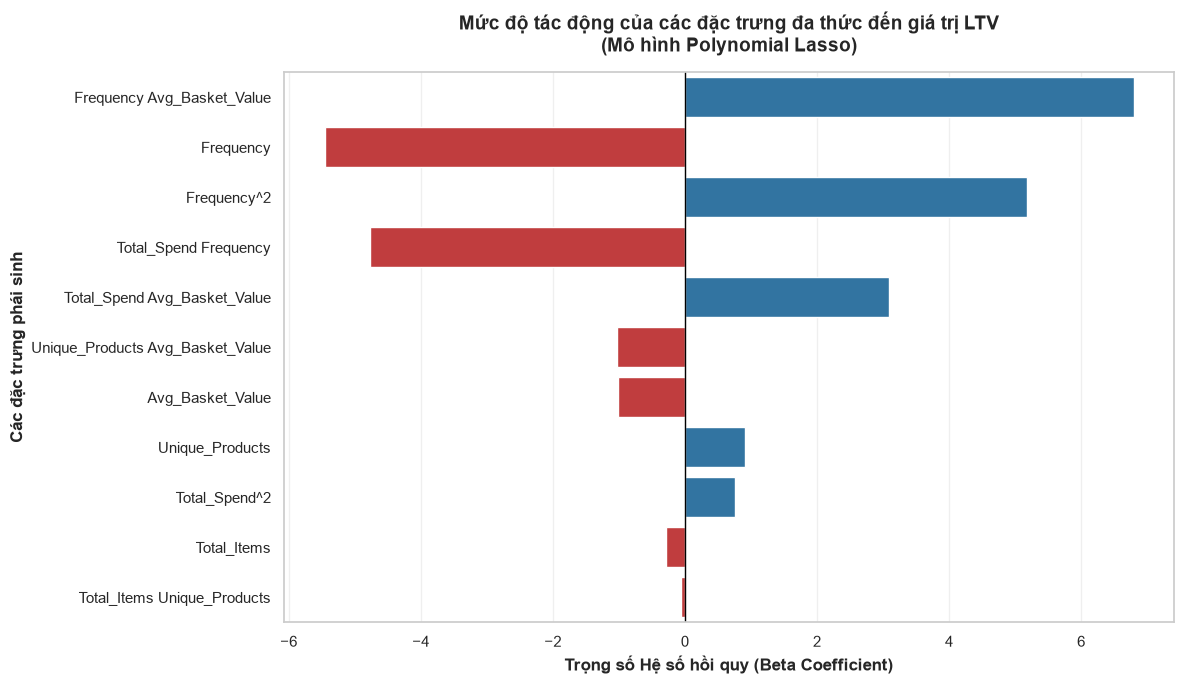

In [11]:
def plot_lasso_coefficients(model, feature_names):
    """
    Hàm vẽ biểu đồ các hệ số hồi quy quan trọng khác 0 của Lasso.
    Tham số:
        model: Mô hình LassoCV đã huấn luyện
        feature_names: Danh sách tên cột tương ứng (X_train_scaled.columns)
    """
    # 1. Tạo DataFrame chứa hệ số
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': model.coef_
    })
    
    # Lọc bỏ các biến bị ép về 0 và sắp xếp theo độ lớn tuyệt đối
    important_features = coef_df[coef_df['Coefficient'] != 0].copy()
    important_features['Abs_Coefficient'] = important_features['Coefficient'].abs()
    important_features = important_features.sort_values(by='Abs_Coefficient', ascending=False)

    # 2. Khởi tạo khung vẽ
    plt.figure(figsize=(12, 7))
    sns.set_theme(style="whitegrid")

    # Vẽ biểu đồ thanh ngang, phân biệt màu sắc dựa trên hệ số âm hay dương
    colors = ['#1f77b4' if x > 0 else '#d62728' for x in important_features['Coefficient']]
    
    barplot = sns.barplot(
        x='Coefficient', 
        y='Feature', 
        data=important_features, 
        palette=colors,
        hue='Feature',
        legend=False
    )
    
    # Thêm đường thẳng mốc 0 để thấy rõ phần âm/dương
    plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
    
    # Định dạng nhãn chữ
    plt.xlabel('Trọng số Hệ số hồi quy (Beta Coefficient)', fontsize=12, fontweight='bold')
    plt.ylabel('Các đặc trưng phái sinh', fontsize=12, fontweight='bold')
    plt.title('Mức độ tác động của các đặc trưng đa thức đến giá trị LTV\n(Mô hình Polynomial Lasso)', fontsize=14, fontweight='bold', pad=15)
    
    plt.tight_layout()
    plt.show()

# CÁCH GỌI HÀM:
plot_lasso_coefficients(lasso_model, X_train_scaled.columns)

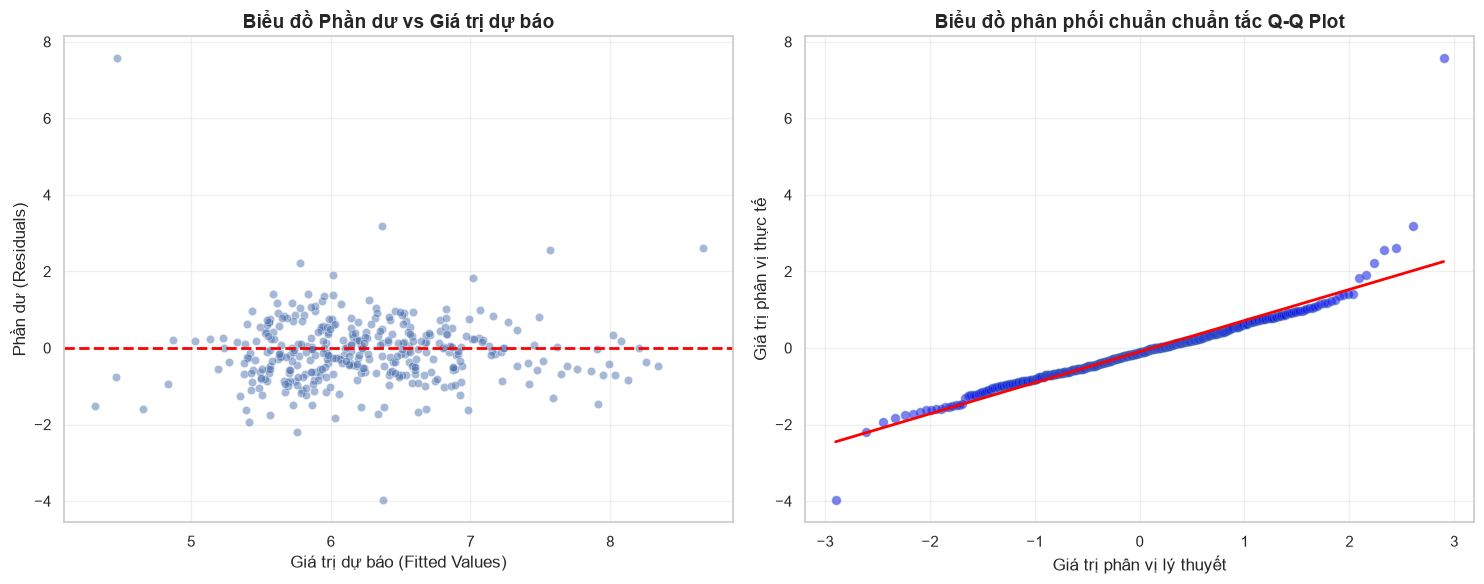

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

def plot_lasso_residuals(model, X_test, y_test):
    """
    Hàm vẽ biểu đồ kiểm định phần dư cho mô hình Lasso trên tập Test.
    Tham số:
        model: Mô hình LassoCV đã huấn luyện
        X_test: Ma trận đặc trưng tập test (đã scale)
        y_test: Biến mục tiêu tập test (đã log)
    """
    # 1. Tính toán giá trị dự báo và phần dư
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    # 2. Khởi tạo khung vẽ (1 hàng, 2 cột)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Đặt phong cách nền trắng kẻ ô cho sang trọng
    sns.set_theme(style="whitegrid")

    # Biểu đồ trái: Residuals vs Fitted
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, ax=axes[0])
    axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[0].set_xlabel('Giá trị dự báo (Fitted Values)', fontsize=12)
    axes[0].set_ylabel('Phần dư (Residuals)', fontsize=12)
    axes[0].set_title('Biểu đồ Phần dư vs Giá trị dự báo', fontsize=14, fontweight='bold')

    # Biểu đồ phải: Normal Q-Q Plot
    stats.probplot(residuals, dist="norm", plot=axes[1])
    axes[1].get_lines()[0].set_markerfacecolor('blue')
    axes[1].get_lines()[0].set_alpha(0.5)
    axes[1].get_lines()[1].set_color('red')
    axes[1].get_lines()[1].set_linewidth(2)
    axes[1].set_title('Biểu đồ phân phối chuẩn chuẩn tắc Q-Q Plot', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Giá trị phân vị lý thuyết', fontsize=12)
    axes[1].set_ylabel('Giá trị phân vị thực tế', fontsize=12)

    plt.tight_layout()
    plt.show()

# CÁCH GỌI HÀM:
plot_lasso_residuals(lasso_model, X_test_scaled, y_test)